<a href="https://colab.research.google.com/github/ibrahimanwarkhalil-jpg/NorthStar_Data_Analytics_Coursework/blob/main/notebooks/Section_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
install.packages(c("DBI", "RSQLite", "dplyr", "ggplot2", "readr", "lubridate"))

library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
list.files()

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "sample_data"         "vehicles.csv"

In [5]:
library(readr)

app_events <- read_csv("app_events.csv", show_col_types = FALSE)
complaints <- read_csv("complaints.csv", show_col_types = FALSE)
customers <- read_csv("customers.csv", show_col_types = FALSE)
data_dictionary <- read_csv("data_dictionary.csv", show_col_types = FALSE)
deliveries <- read_csv("deliveries.csv", show_col_types = FALSE)
drivers <- read_csv("drivers.csv", show_col_types = FALSE)
hubs <- read_csv("hubs.csv", show_col_types = FALSE)
incidents <- read_csv("incidents.csv", show_col_types = FALSE)
orders <- read_csv("orders.csv", show_col_types = FALSE)
vehicles <- read_csv("vehicles.csv", show_col_types = FALSE)

In [6]:
head(app_events)
head(complaints)
head(customers)
head(deliveries)
head(drivers)
head(hubs)
head(incidents)
head(orders)
head(vehicles)

event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
<chr>,<chr>,<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AE00001,C0488,NA,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
AE00005,C0506,NA,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1
AE00006,C0498,O01196,2025-02-08 09:50:00,track_order,S66655,Web,West,499,1


complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
D002,Central,FullTime,4,42.4,3.94,Evening,1
D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1
D004,Airport,PartTime,13,88.9,4.75,Morning,1
D005,north,FullTime,3,69.7,4.14,Morning,1
D006,CENTRAL,FullTime,8,78.8,4.38,Flexible,1


hub_id,hub_name,zone,hub_type,capacity_score
<chr>,<chr>,<chr>,<chr>,<dbl>
H01,North Exchange,North,Dispatch,82
H02,South Link,South,Dispatch,78
H03,East Dock,East,Warehouse,74
H04,West Gate,West,Dispatch,69
H05,Central Core,Central,Control,88
H06,Airport Hub,Airport,Dispatch,71


incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
<chr>,<chr>,<chr>,<dttm>,<chr>,<chr>,<dbl>
I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0
I0006,DL00634,CustomerNoShow,2025-08-08 21:26:00,High,PendingVendor,19.9


order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
<chr>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
V004,Hybrid,RiverSide,2024-06-07 13:21:00,NA,36310,Active,v2.2
V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2
V006,EV,Central,2025-11-22 06:39:00,78.6,141381,Active,v2.1


In [7]:
dim(app_events)
dim(complaints)
dim(customers)
dim(deliveries)
dim(drivers)
dim(hubs)
dim(incidents)
dim(orders)
dim(vehicles)

[1] 640  10

[1] 320  10

[1] 650   9

[1] 950  13

[1] 170   8

[1] 8 5

[1] 280   7

[1] 1250   11

[1] 120   8

In [8]:
names(app_events)
names(complaints)
names(customers)
names(deliveries)
names(drivers)
names(hubs)
names(incidents)
names(orders)
names(vehicles)

[1] "event_id"        "customer_id"     "order_id"        "event_timestamp"
 [5] "event_type"      "session_id"      "device_type"     "zone_context"   
 [9] "api_latency_ms"  "success_flag"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "driver_id"        "base_zone"        "employment_type"  "years_experience"
[5] "training_score"   "driver_rating"    "shift_preference" "active_flag"

[1] "hub_id"         "hub_name"       "zone"           "hub_type"      
[5] "capacity_score"

[1] "incident_id"       "delivery_id"       "incident_type"    
[4] "reported_at"       "severity"          "resolution_status"
[7] "resolved_hours"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "vehicle_id"         "vehicle_type"       "assigned_zone"     
[4] "commission_date"    "battery_health_pct" "odometer_km"       
[7] "maintenance_status" "telematics_version"

In [9]:
con <- dbConnect(SQLite(), ":memory:")

dbWriteTable(con, "app_events", app_events, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "customers", customers, overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents, overwrite = TRUE)
dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "vehicles", vehicles, overwrite = TRUE)

dbListTables(con)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

In [10]:
query_select <- "
SELECT
    order_id,
    customer_id,
    service_type,
    pickup_zone,
    dropoff_zone,
    priority_level,
    order_value,
    booking_channel
FROM orders
WHERE priority_level = 'High'
ORDER BY order_value DESC
LIMIT 5;
"
high_priority_orders <- dbGetQuery(con, query_select)
high_priority_orders

order_id,customer_id,service_type,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
O00144,C0063,Business,Riverside,Central,High,288.86,App
O00790,C0028,Retail,Airport,WEST,High,283.08,Web
O00799,C0289,Passenger,EAST,SOUTH,High,260.00,Web
O00115,C0157,Passenger,East,north,High,256.93,Web
O00874,C0360,Parcel,East,West,High,246.43,Phone


In [11]:
dbExecute(con, "
INSERT INTO complaints
(complaint_id, customer_id, order_id, complaint_type, channel, severity, created_at, status, resolution_days, compensation_amount)
VALUES
('CP9999', 'C0001', 'O00001', 'LateDelivery', 'App', 'High', '2026-05-11 10:00:00', 'Open', 0, 25.00);
")
insert_result <- dbGetQuery(con, "
SELECT *
FROM complaints
WHERE complaint_id = 'CP9999';
")
insert_result

[1] 1

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
CP9999,C0001,O00001,LateDelivery,App,High,2026-05-11 10:00:00,Open,0,25


In [12]:
dbExecute(con, "
UPDATE complaints
SET status = 'Escalated',
    resolution_days = 2
WHERE complaint_id = 'CP9999';
")
update_result <- dbGetQuery(con, "
SELECT complaint_id, customer_id, order_id, complaint_type, severity, status, resolution_days
FROM complaints
WHERE complaint_id = 'CP9999';
")
update_result

[1] 1

complaint_id,customer_id,order_id,complaint_type,severity,status,resolution_days
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CP9999,C0001,O00001,LateDelivery,High,Escalated,2


In [13]:
dbExecute(con, "
DELETE FROM complaints
WHERE complaint_id = 'CP9999';
")
delete_result <- dbGetQuery(con, "
SELECT *
FROM complaints
WHERE complaint_id = 'CP9999';
")
delete_result

[1] 1

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>


In [14]:
query_delivery_status <- "
SELECT
    h.zone,
    d.delivery_status,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(d.route_distance_km), 2) AS avg_route_distance,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_fuel_or_charge_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM deliveries d
LEFT JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.zone, d.delivery_status
ORDER BY h.zone, total_deliveries DESC;
"
delivery_status_summary <- dbGetQuery(con, query_delivery_status)
delivery_status_summary

zone,delivery_status,total_deliveries,avg_route_distance,avg_fuel_or_charge_cost,avg_customer_rating
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Airport,OnTime,62,14.03,13.14,4.43
Airport,Delayed,27,14.97,13.60,3.10
Airport,Failed,15,14.98,13.54,3.07
Central,OnTime,147,13.49,12.40,4.26
Central,Failed,49,13.35,13.51,3.07
Central,Delayed,47,13.83,12.51,2.99
East,OnTime,85,14.03,12.59,4.21
East,Delayed,23,14.96,12.97,3.15
East,Failed,11,17.31,13.47,2.91


In [15]:
query_failure_rate <- "
SELECT
    h.zone,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status IN ('Failed', 'Delayed') THEN 1 ELSE 0 END) AS failed_or_delayed_deliveries,
    ROUND(
        SUM(CASE WHEN d.delivery_status IN ('Failed', 'Delayed') THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS failure_delay_rate_percent,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
FROM deliveries d
LEFT JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.zone
ORDER BY failure_delay_rate_percent DESC;
"
failure_rate <- dbGetQuery(con, query_failure_rate)
failure_rate

zone,total_deliveries,failed_or_delayed_deliveries,failure_delay_rate_percent,avg_rating
<chr>,<int>,<int>,<dbl>,<dbl>
Airport,104,42,40.38,3.88
Central,243,96,39.51,3.78
West,127,44,34.65,3.92
South,106,36,33.96,3.95
Riverside,115,39,33.91,3.88
North,136,43,31.62,3.84
East,119,34,28.57,3.90


In [16]:
query_complaints_service <- "
SELECT
    o.service_type,
    c.severity,
    COUNT(*) AS total_complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation
FROM complaints c
LEFT JOIN orders o
ON c.order_id = o.order_id
GROUP BY o.service_type, c.severity
ORDER BY total_complaints DESC;
"
complaints_service <- dbGetQuery(con, query_complaints_service)
complaints_service

service_type,severity,total_complaints,avg_resolution_days,total_compensation
<chr>,<chr>,<int>,<dbl>,<dbl>
Retail,Medium,51,6.35,914.91
Passenger,Medium,45,5.76,738.77
Parcel,Medium,36,6.00,558.81
Business,Medium,23,6.96,415.24
Parcel,High,22,13.86,668.81
Passenger,High,22,12.82,788.98
Parcel,Low,19,6.37,236.03
Retail,Low,19,8.11,133.23
Medical,Medium,17,6.00,254.88


In [17]:
query_driver_override <- "
SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    dr.years_experience,
    dr.training_score,
    dr.driver_rating,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(d.manual_route_override_count) AS total_manual_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides_per_delivery,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM deliveries d
LEFT JOIN drivers dr
ON d.driver_id = dr.driver_id
GROUP BY d.driver_id, dr.base_zone, dr.employment_type, dr.years_experience, dr.training_score, dr.driver_rating
HAVING total_deliveries >= 3
ORDER BY total_manual_overrides DESC
LIMIT 5;
"
driver_override <- dbGetQuery(con, query_driver_override)
driver_override

driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,total_deliveries,total_manual_overrides,avg_overrides_per_delivery,avg_customer_rating
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
D127,CENTRAL,FullTime,10,61.5,4.19,6,17,2.83,4.10
D087,north,Contract,13,73.3,4.43,12,16,1.33,3.82
D130,WEST,FullTime,8,71.2,3.64,8,16,2.00,3.80
D108,South,FullTime,10,70.6,4.33,11,15,1.36,4.41
D131,SOUTH,FullTime,9,86.7,4.26,9,15,1.67,3.66


In [18]:
query_vehicle_risk <- "
SELECT
    vehicle_id,
    vehicle_type,
    assigned_zone,
    battery_health_pct,
    odometer_km,
    maintenance_status,
    telematics_version
FROM vehicles
WHERE battery_health_pct < 70
   OR maintenance_status IN ('InRepair', 'NeedsService')
ORDER BY battery_health_pct ASC, odometer_km DESC;
"
vehicle_risk <- dbGetQuery(con, query_vehicle_risk)
vehicle_risk

vehicle_id,vehicle_type,assigned_zone,battery_health_pct,odometer_km,maintenance_status,telematics_version
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
V025,Diesel,AIRPORT,42.0,52074,Active,v2.1
V084,CargoVan,Riverside,47.6,53872,InRepair,v2.1
V087,Hybrid,AIRPORT,49.7,116811,Active,v2.1
V010,CargoVan,NORTH,50.7,129032,InRepair,v2.1
V108,Diesel,AIRPORT,54.6,141290,InRepair,v1.9
V049,Diesel,East,55.9,15278,Active,v2.2
V012,Hybrid,SOUTH,56.2,52021,Active,v2.1
V037,CargoVan,South,56.6,52146,InRepair,v1.9
V067,Hybrid,Ctr,57.3,176145,Active,v2.0


In [19]:
query_incident_analysis <- "
SELECT
    incident_type,
    severity,
    resolution_status,
    COUNT(*) AS total_incidents,
    ROUND(AVG(resolved_hours), 2) AS avg_resolved_hours,
    MAX(resolved_hours) AS max_resolved_hours
FROM incidents
GROUP BY incident_type, severity, resolution_status
ORDER BY total_incidents DESC;
"
incident_analysis <- dbGetQuery(con, query_incident_analysis)
incident_analysis

incident_type,severity,resolution_status,total_incidents,avg_resolved_hours,max_resolved_hours
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
CustomerNoShow,Medium,Closed,10,14.86,25.6
ProofMissing,Low,Closed,10,13.36,41.7
RouteDeviation,Low,Closed,10,17.05,28.0
AppSyncError,Medium,PendingVendor,8,14.29,23.7
BatteryAlert,Medium,Closed,7,11.26,24.3
TemperatureIssue,Medium,Closed,7,15.76,31.4
BatteryAlert,Medium,Open,6,9.70,17.7
CustomerNoShow,Low,Open,6,15.47,25.3
ProofMissing,Medium,Closed,6,10.38,15.5


In [20]:
query_app_events <- "
SELECT
    event_type,
    device_type,
    zone_context,
    COUNT(*) AS total_events,
    ROUND(AVG(api_latency_ms), 2) AS avg_api_latency,
    SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) AS failed_events,
    ROUND(SUM(CASE WHEN success_flag = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_rate_percent
FROM app_events
GROUP BY event_type, device_type, zone_context
ORDER BY failure_rate_percent DESC, avg_api_latency DESC;
"
app_event_analysis <- dbGetQuery(con, query_app_events)
app_event_analysis

event_type,device_type,zone_context,total_events,avg_api_latency,failed_events,failure_rate_percent
<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>
chat_escalated,iOS,Central,1,1402.00,1,100.00
chat_escalated,Web,CENTRAL,1,998.00,1,100.00
chat_escalated,Android,Riverside,2,768.00,2,100.00
chat_escalated,Web,Central,1,732.00,1,100.00
payment_retry,iOS,north,1,504.00,1,100.00
chat_escalated,Android,North,3,498.00,3,100.00
chat_escalated,Web,Airport,1,474.00,1,100.00
chat_escalated,iOS,AIRPORT,1,426.00,1,100.00
payment_retry,Android,Riverside,1,404.00,1,100.00


In [21]:
delivery_transformed <- deliveries %>%
  mutate(
    performance_category = case_when(
      delivery_status == "OnTime" ~ "Successful",
      delivery_status == "Delayed" ~ "Delayed",
      delivery_status == "Failed" ~ "Failed",
      TRUE ~ "Other"
    ),
    cost_category = case_when(
      fuel_or_charge_cost < 10 ~ "Low cost",
      fuel_or_charge_cost < 20 ~ "Medium cost",
      TRUE ~ "High cost"
    )
  )
head(delivery_transformed)

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,performance_category,cost_category
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05,Failed,Medium cost
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41,Successful,Medium cost
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51,Successful,Low cost
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62,Delayed,Medium cost
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22,Successful,Low cost
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58,Delayed,Low cost


In [22]:
delivery_summary <- delivery_transformed %>%
  group_by(performance_category) %>%
  summarise(
    total_deliveries = n(),
    avg_distance = mean(route_distance_km, na.rm = TRUE),
    avg_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_manual_overrides = mean(manual_route_override_count, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(total_deliveries))
delivery_summary

performance_category,total_deliveries,avg_distance,avg_cost,avg_rating,avg_manual_overrides
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Successful,616,13.77636,12.67805,4.283273,0.9204545
Delayed,202,14.67025,13.13871,3.114975,1.0742574
Failed,132,13.36530,13.14795,3.049313,1.0378788


In [23]:
customer_complaint_risk <- customers %>%
  left_join(complaints, by = "customer_id") %>%
  group_by(customer_type, account_status) %>%
  summarise(
    total_customers_or_cases = n(),
    avg_loyalty_score = mean(loyalty_score, na.rm = TRUE),
    avg_app_engagement = mean(app_engagement_score, na.rm = TRUE),
    complaint_count = sum(!is.na(complaint_id)),
    .groups = "drop"
  ) %>%
  arrange(desc(complaint_count))
customer_complaint_risk

customer_type,account_status,total_customers_or_cases,avg_loyalty_score,avg_app_engagement,complaint_count
<chr>,<chr>,<int>,<dbl>,<dbl>,<int>
Consumer,Active,472,60.02696,57.90636,214
SME,Active,112,57.34766,58.01250,43
Consumer,Dormant,61,59.60893,58.77705,22
Enterprise,Active,46,58.97111,55.55870,19
Enterprise,Dormant,8,62.45000,53.16250,7
Consumer,Suspended,13,64.58462,56.06923,6
SME,Dormant,16,53.51250,53.87500,4
SME,Suspended,6,58.26000,61.71667,3
Enterprise,Suspended,3,69.23333,68.10000,2


In [24]:
delivery_statistics <- deliveries %>%
  summarise(
    mean_distance = mean(route_distance_km, na.rm = TRUE),
    median_distance = median(route_distance_km, na.rm = TRUE),
    sd_distance = sd(route_distance_km, na.rm = TRUE),
    mean_cost = mean(fuel_or_charge_cost, na.rm = TRUE),
    median_cost = median(fuel_or_charge_cost, na.rm = TRUE),
    sd_cost = sd(fuel_or_charge_cost, na.rm = TRUE),
    mean_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    min_rating = min(customer_rating_post_delivery, na.rm = TRUE),
    max_rating = max(customer_rating_post_delivery, na.rm = TRUE)
  )
delivery_statistics

mean_distance,median_distance,sd_distance,mean_cost,median_cost,sd_cost,mean_rating,min_rating,max_rating
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13.90932,12.84,7.477907,12.84129,12.645,4.336468,3.864679,1,5


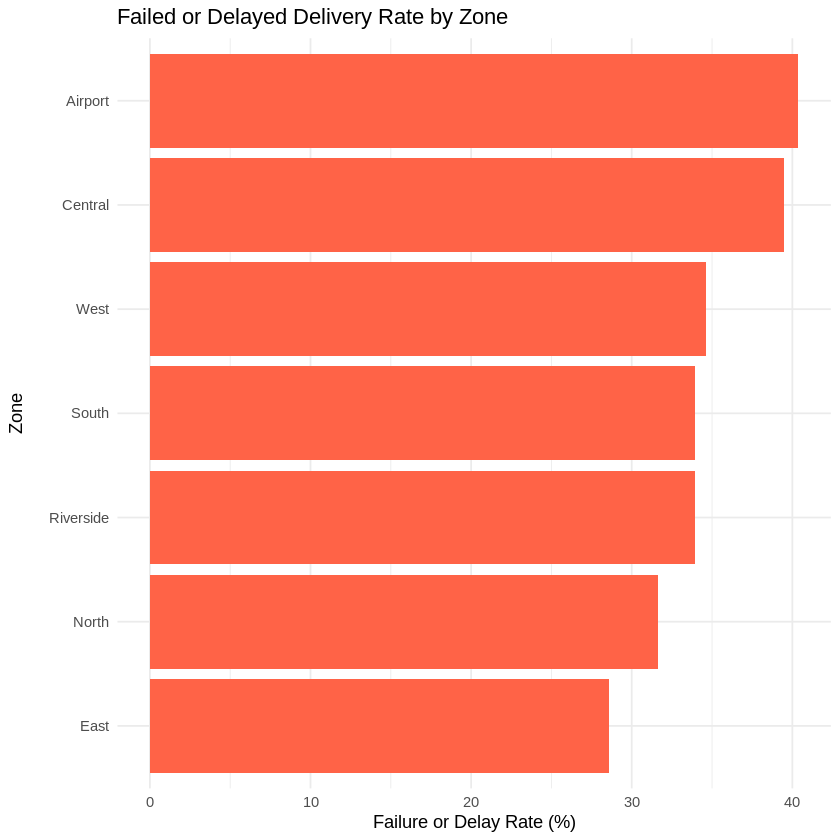

In [25]:
failure_rate_plot <- dbGetQuery(con, "
SELECT
    h.zone,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status IN ('Failed', 'Delayed') THEN 1 ELSE 0 END) AS failed_or_delayed,
    ROUND(SUM(CASE WHEN d.delivery_status IN ('Failed', 'Delayed') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS failure_delay_rate
FROM deliveries d
LEFT JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.zone
ORDER BY failure_delay_rate DESC;
")
ggplot(failure_rate_plot, aes(x = reorder(zone, failure_delay_rate), y = failure_delay_rate)) +
  geom_col(fill = "tomato") +
  coord_flip() +
  labs(
    title = "Failed or Delayed Delivery Rate by Zone",
    x = "Zone",
    y = "Failure or Delay Rate (%)"
  ) +
  theme_minimal()

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


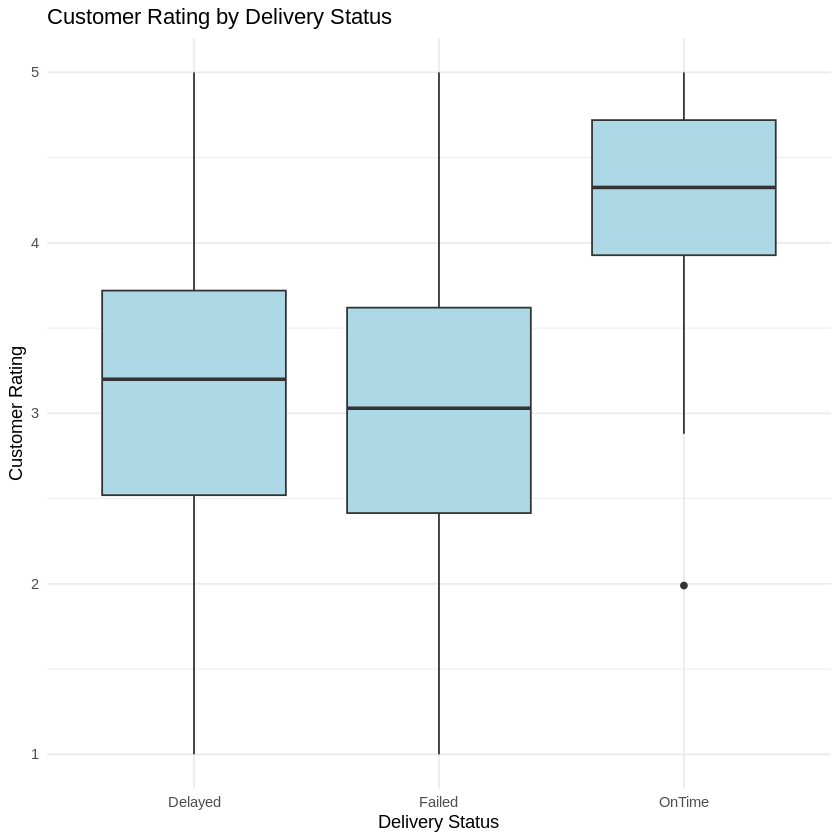

In [26]:
ggplot(deliveries, aes(x = delivery_status, y = customer_rating_post_delivery)) +
  geom_boxplot(fill = "lightblue") +
  labs(
    title = "Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Customer Rating"
  ) +
  theme_minimal()

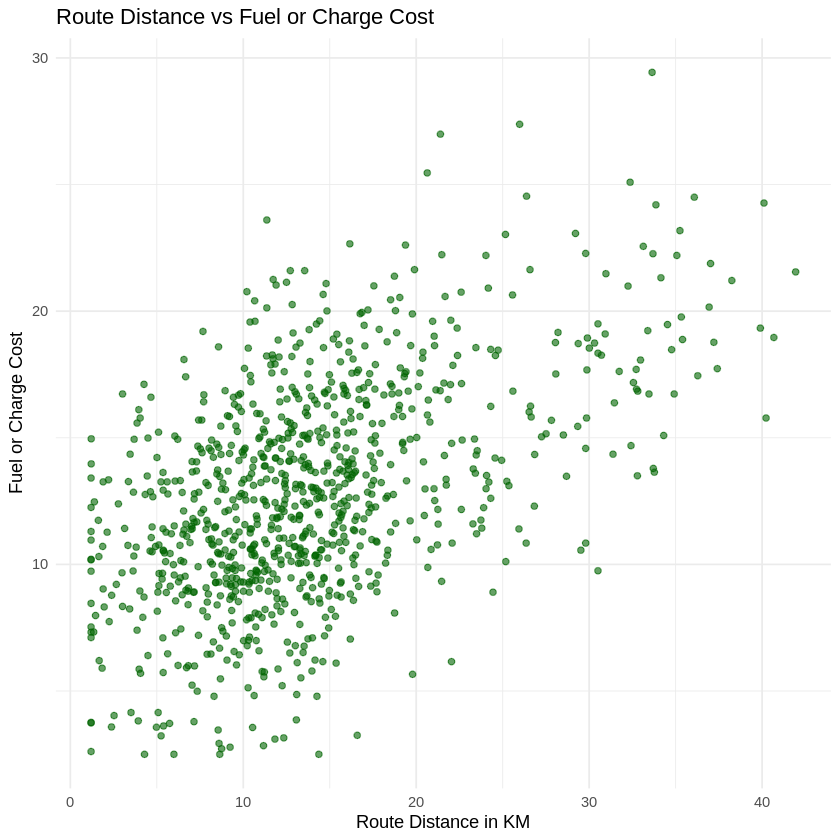

In [27]:
ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.6, color = "darkgreen") +
  labs(
    title = "Route Distance vs Fuel or Charge Cost",
    x = "Route Distance in KM",
    y = "Fuel or Charge Cost"
  ) +
  theme_minimal()

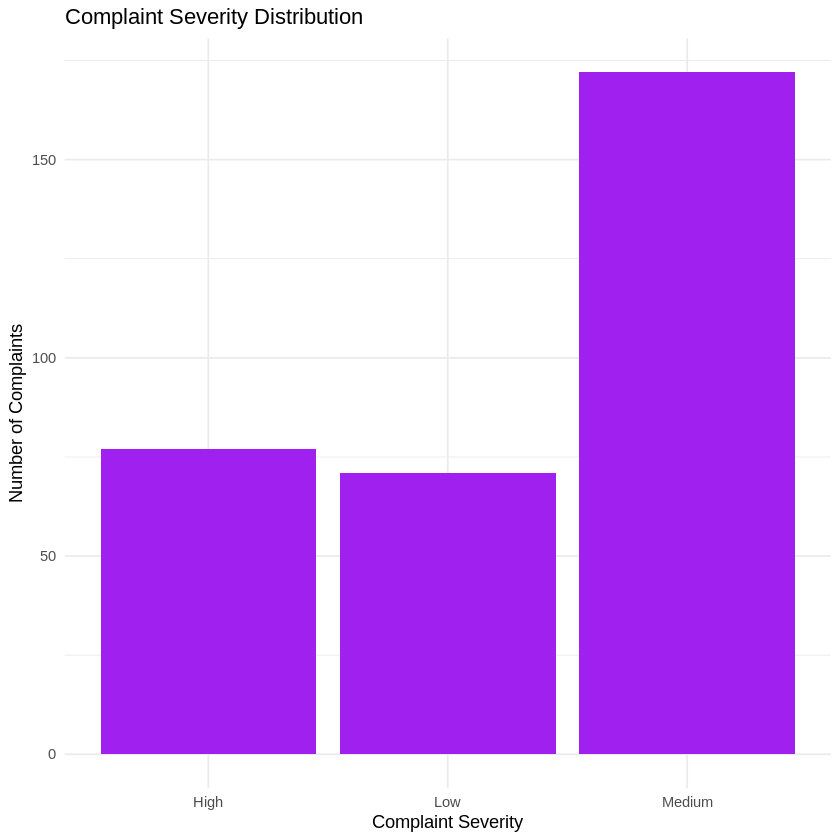

In [28]:
ggplot(complaints, aes(x = severity)) +
  geom_bar(fill = "purple") +
  labs(
    title = "Complaint Severity Distribution",
    x = "Complaint Severity",
    y = "Number of Complaints"
  ) +
  theme_minimal()

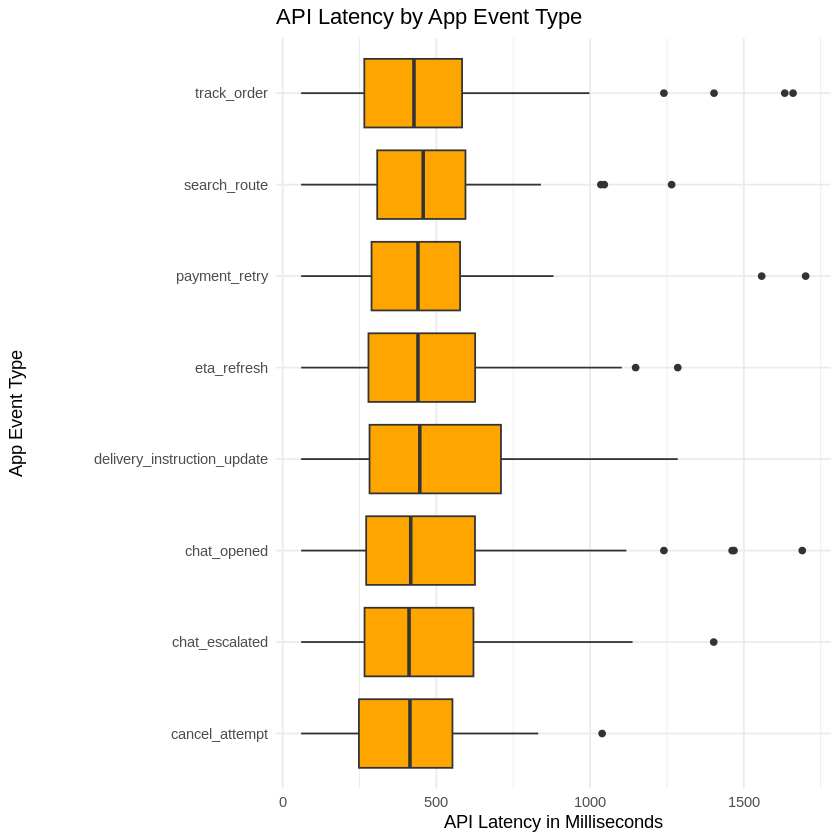

In [29]:
ggplot(app_events, aes(x = event_type, y = api_latency_ms)) +
  geom_boxplot(fill = "orange") +
  coord_flip() +
  labs(
    title = "API Latency by App Event Type",
    x = "App Event Type",
    y = "API Latency in Milliseconds"
  ) +
  theme_minimal()

In [30]:
dbExecute(con, "CREATE INDEX idx_orders_customer ON orders(customer_id);")
dbExecute(con, "CREATE INDEX idx_orders_service_type ON orders(service_type);")
dbExecute(con, "CREATE INDEX idx_orders_zones ON orders(pickup_zone, dropoff_zone);")

dbExecute(con, "CREATE INDEX idx_deliveries_order ON deliveries(order_id);")
dbExecute(con, "CREATE INDEX idx_deliveries_driver ON deliveries(driver_id);")
dbExecute(con, "CREATE INDEX idx_deliveries_vehicle ON deliveries(vehicle_id);")
dbExecute(con, "CREATE INDEX idx_deliveries_hub ON deliveries(hub_id);")
dbExecute(con, "CREATE INDEX idx_deliveries_status ON deliveries(delivery_status);")

dbExecute(con, "CREATE INDEX idx_complaints_customer ON complaints(customer_id);")
dbExecute(con, "CREATE INDEX idx_complaints_order ON complaints(order_id);")
dbExecute(con, "CREATE INDEX idx_complaints_severity ON complaints(severity);")

dbExecute(con, "CREATE INDEX idx_incidents_delivery ON incidents(delivery_id);")
dbExecute(con, "CREATE INDEX idx_app_events_customer ON app_events(customer_id);")
dbExecute(con, "CREATE INDEX idx_app_events_order ON app_events(order_id);")

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

...

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

In [31]:
dbGetQuery(con, "PRAGMA index_list('deliveries');")
dbGetQuery(con, "PRAGMA index_list('complaints');")
dbGetQuery(con, "PRAGMA index_list('orders');")

seq,name,unique,origin,partial
<int>,<chr>,<int>,<chr>,<int>
0,idx_deliveries_status,0,c,0
1,idx_deliveries_hub,0,c,0
2,idx_deliveries_vehicle,0,c,0
3,idx_deliveries_driver,0,c,0
4,idx_deliveries_order,0,c,0


seq,name,unique,origin,partial
<int>,<chr>,<int>,<chr>,<int>
0,idx_complaints_severity,0,c,0
1,idx_complaints_order,0,c,0
2,idx_complaints_customer,0,c,0


seq,name,unique,origin,partial
<int>,<chr>,<int>,<chr>,<int>
0,idx_orders_zones,0,c,0
1,idx_orders_service_type,0,c,0
2,idx_orders_customer,0,c,0


In [32]:
dbGetQuery(con, "
EXPLAIN QUERY PLAN
SELECT
    d.delivery_id,
    d.order_id,
    d.delivery_status,
    c.complaint_type,
    c.severity
FROM deliveries d
LEFT JOIN complaints c
ON d.order_id = c.order_id
WHERE d.delivery_status = 'Failed';
")

id,parent,notused,detail
<int>,<int>,<int>,<chr>
5,0,61,SEARCH d USING INDEX idx_deliveries_status (delivery_status=?)
10,0,61,SEARCH c USING INDEX idx_complaints_order (order_id=?) LEFT-JOIN


In [33]:
query_high_value_failed <- "
SELECT
    o.order_id,
    o.customer_id,
    o.service_type,
    o.priority_level,
    o.order_value,
    d.delivery_status,
    d.route_distance_km,
    d.fuel_or_charge_cost,
    d.customer_rating_post_delivery
FROM orders o
LEFT JOIN deliveries d
ON o.order_id = d.order_id
WHERE d.delivery_status IN ('Failed', 'Delayed')
ORDER BY o.order_value DESC
LIMIT 15;
"

high_value_failed <- dbGetQuery(con, query_high_value_failed)
high_value_failed

order_id,customer_id,service_type,priority_level,order_value,delivery_status,route_distance_km,fuel_or_charge_cost,customer_rating_post_delivery
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
O00980,C0545,Parcel,Medium,510.06,Delayed,19.05,20.54,1.83
O00892,C0157,Passenger,Medium,326.38,Delayed,32.56,17.18,NA
O01207,C0197,Business,Medium,321.68,Failed,16.96,16.98,NA
O00052,C0150,Retail,Medium,293.65,Delayed,13.60,16.00,3.72
O00144,C0063,Business,High,288.86,Delayed,15.53,11.71,3.54
O01107,C0182,Business,Medium,282.35,Delayed,37.41,17.73,4.22
O01112,C0301,Business,Critical,278.14,Failed,12.99,16.82,4.06
O00173,C0371,Passenger,Critical,249.32,Failed,10.92,9.05,2.87
O00326,C0178,Passenger,Medium,242.48,Delayed,13.55,15.10,2.51


In [34]:
query_customer_compensation <- "
SELECT
    cu.customer_type,
    cu.account_status,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.resolution_days), 2) AS avg_resolution_days,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
FROM complaints c
LEFT JOIN customers cu
ON c.customer_id = cu.customer_id
GROUP BY cu.customer_type, cu.account_status
ORDER BY total_compensation DESC;
"

customer_compensation <- dbGetQuery(con, query_customer_compensation)
customer_compensation

customer_type,account_status,total_complaints,avg_resolution_days,total_compensation,avg_compensation
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Consumer,Active,214,7.79,4168.00,20.33
SME,Active,43,8.09,758.31,18.96
Consumer,Dormant,22,8.09,502.92,22.86
Enterprise,Active,19,8.32,371.71,21.87
Enterprise,Dormant,7,8.29,135.48,19.35
Consumer,Suspended,6,9.33,93.19,23.30
SME,Suspended,3,4.67,58.18,19.39
SME,Dormant,4,9.75,51.66,12.91
Enterprise,Suspended,2,9.50,18.74,9.37


In [35]:
query_hub_capacity <- "
SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status IN ('Failed', 'Delayed') THEN 1 ELSE 0 END) AS failed_or_delayed,
    ROUND(
        SUM(CASE WHEN d.delivery_status IN ('Failed', 'Delayed') THEN 1 ELSE 0 END) * 100.0 / COUNT(d.delivery_id),
        2
    ) AS failure_delay_rate_percent,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating
FROM hubs h
LEFT JOIN deliveries d
ON h.hub_id = d.hub_id
GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score
ORDER BY failure_delay_rate_percent DESC;
"

hub_capacity <- dbGetQuery(con, query_hub_capacity)
hub_capacity

hub_id,hub_name,zone,hub_type,capacity_score,total_deliveries,failed_or_delayed,failure_delay_rate_percent,avg_customer_rating
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
H05,Central Core,Central,Control,88,115,48,41.74,3.67
H06,Airport Hub,Airport,Dispatch,71,104,42,40.38,3.88
H08,Midtown Relay,Central,Charging,63,128,48,37.50,3.88
H04,West Gate,West,Dispatch,69,127,44,34.65,3.92
H02,South Link,South,Dispatch,78,106,36,33.96,3.95
H07,Riverside Hub,Riverside,Warehouse,66,115,39,33.91,3.88
H01,North Exchange,North,Dispatch,82,136,43,31.62,3.84
H03,East Dock,East,Warehouse,74,119,34,28.57,3.90


In [36]:
query_app_complaints <- "
SELECT
    a.event_type,
    a.device_type,
    a.zone_context,
    COUNT(a.event_id) AS total_app_events,
    SUM(CASE WHEN a.success_flag = 0 THEN 1 ELSE 0 END) AS failed_app_events,
    ROUND(
        SUM(CASE WHEN a.success_flag = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(a.event_id),
        2
    ) AS app_failure_rate_percent,
    COUNT(DISTINCT c.complaint_id) AS linked_complaints,
    ROUND(AVG(a.api_latency_ms), 2) AS avg_api_latency
FROM app_events a
LEFT JOIN complaints c
ON a.order_id = c.order_id
GROUP BY a.event_type, a.device_type, a.zone_context
ORDER BY linked_complaints DESC, app_failure_rate_percent DESC;
"

app_complaints <- dbGetQuery(con, query_app_complaints)
app_complaints

event_type,device_type,zone_context,total_app_events,failed_app_events,app_failure_rate_percent,linked_complaints,avg_api_latency
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<dbl>
delivery_instruction_update,iOS,RiverSide,5,0,0.00,4,587.20
search_route,Android,SOUTH,11,0,0.00,4,483.82
chat_opened,Android,AIRPORT,4,0,0.00,3,741.25
chat_opened,Android,Central,4,0,0.00,3,410.50
chat_opened,Android,NORTH,4,0,0.00,3,358.75
chat_opened,Android,WEST,6,0,0.00,3,274.50
eta_refresh,Android,AIRPORT,5,0,0.00,3,577.00
eta_refresh,Android,Airport,3,0,0.00,3,652.00
eta_refresh,iOS,WEST,6,0,0.00,3,394.83


In [37]:
query_incident_rating <- "
SELECT
    i.incident_type,
    i.severity,
    i.resolution_status,
    COUNT(i.incident_id) AS total_incidents,
    ROUND(AVG(i.resolved_hours), 2) AS avg_resolved_hours,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_customer_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_delivery_cost
FROM incidents i
LEFT JOIN deliveries d
ON i.delivery_id = d.delivery_id
GROUP BY i.incident_type, i.severity, i.resolution_status
ORDER BY total_incidents DESC;
"

incident_rating <- dbGetQuery(con, query_incident_rating)
incident_rating

incident_type,severity,resolution_status,total_incidents,avg_resolved_hours,avg_customer_rating,avg_delivery_cost
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
CustomerNoShow,Medium,Closed,10,14.86,3.55,14.50
ProofMissing,Low,Closed,10,13.36,4.12,11.44
RouteDeviation,Low,Closed,10,17.05,3.85,13.58
AppSyncError,Medium,PendingVendor,8,14.29,3.87,11.34
BatteryAlert,Medium,Closed,7,11.26,3.77,14.11
TemperatureIssue,Medium,Closed,7,15.76,3.73,15.65
BatteryAlert,Medium,Open,6,9.70,3.53,13.58
CustomerNoShow,Low,Open,6,15.47,4.25,13.56
ProofMissing,Medium,Closed,6,10.38,4.20,12.37


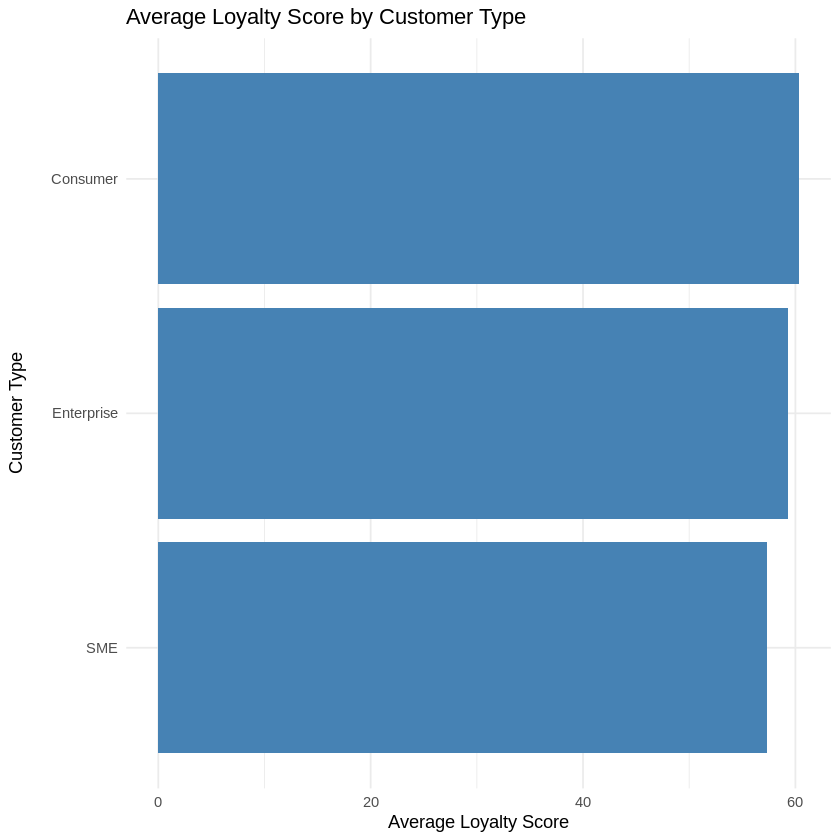

In [38]:
customer_loyalty_plot <- customers %>%
  group_by(customer_type) %>%
  summarise(
    avg_loyalty_score = mean(loyalty_score, na.rm = TRUE),
    total_customers = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(avg_loyalty_score))

ggplot(customer_loyalty_plot, aes(x = reorder(customer_type, avg_loyalty_score), y = avg_loyalty_score)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Average Loyalty Score by Customer Type",
    x = "Customer Type",
    y = "Average Loyalty Score"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


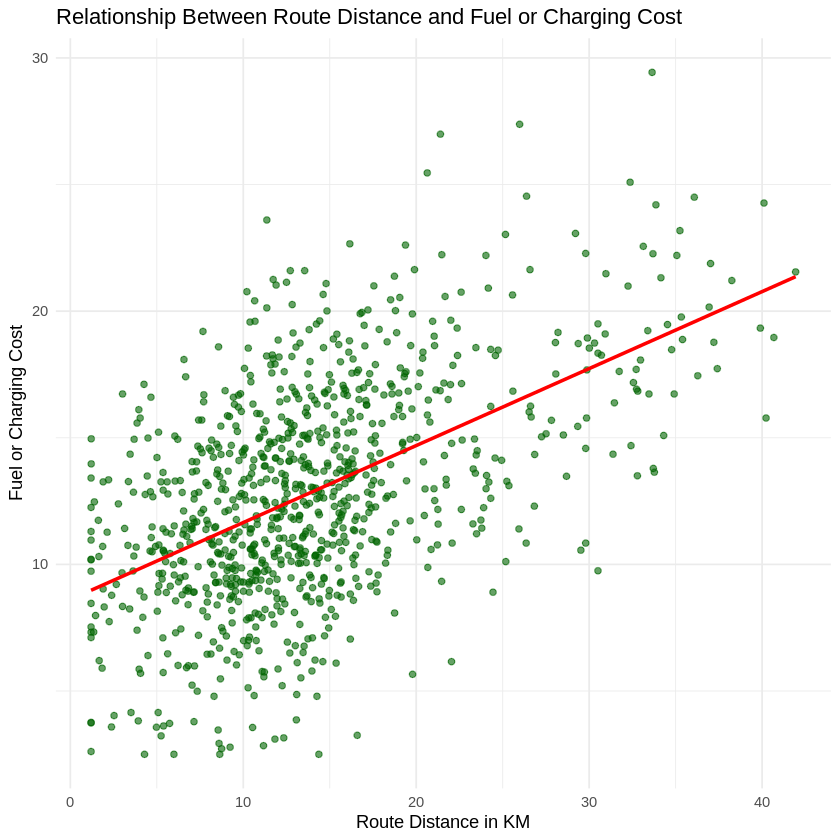

In [39]:
ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.6, color = "darkgreen") +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  labs(
    title = "Relationship Between Route Distance and Fuel or Charging Cost",
    x = "Route Distance in KM",
    y = "Fuel or Charging Cost"
  ) +
  theme_minimal()

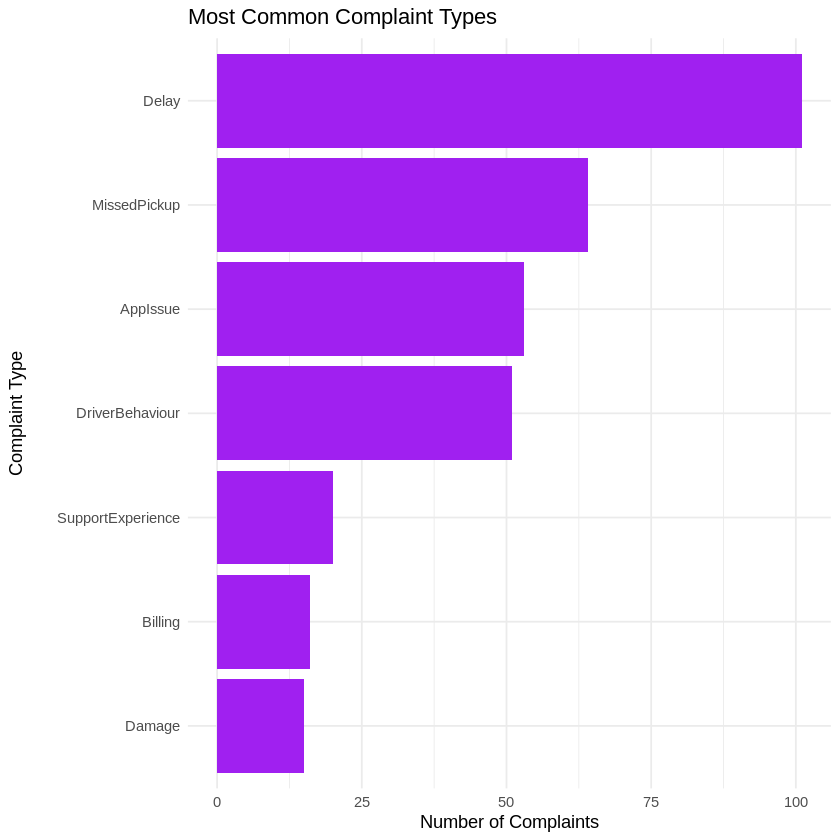

In [40]:
complaint_type_plot <- complaints %>%
  group_by(complaint_type) %>%
  summarise(
    total_complaints = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(total_complaints))

ggplot(complaint_type_plot, aes(x = reorder(complaint_type, total_complaints), y = total_complaints)) +
  geom_col(fill = "purple") +
  coord_flip() +
  labs(
    title = "Most Common Complaint Types",
    x = "Complaint Type",
    y = "Number of Complaints"
  ) +
  theme_minimal()

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


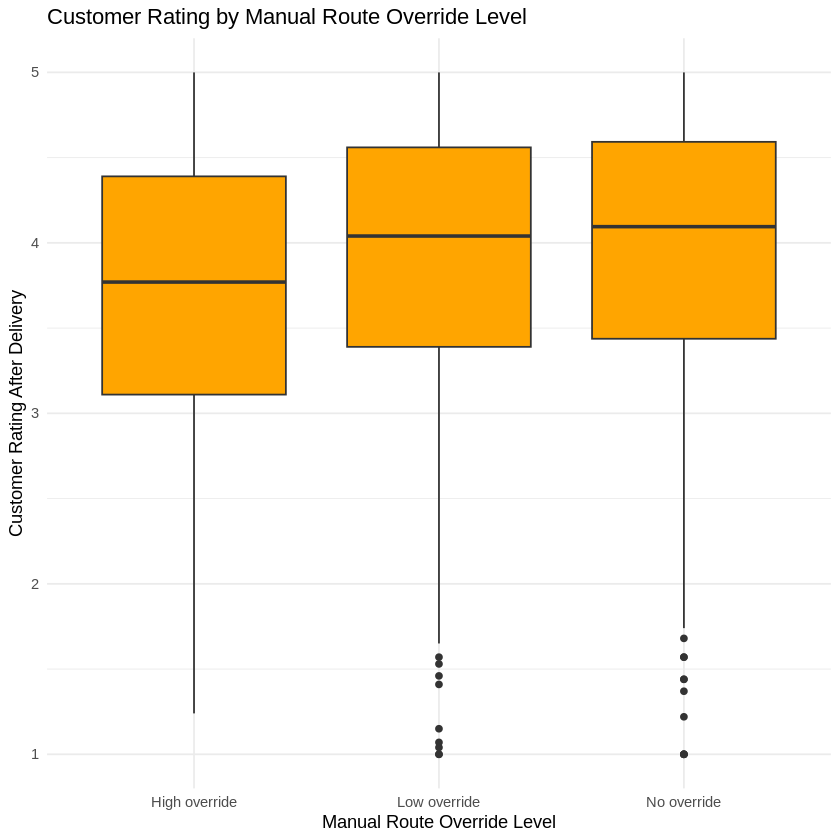

In [41]:
deliveries_override_group <- deliveries %>%
  mutate(
    override_group = case_when(
      manual_route_override_count == 0 ~ "No override",
      manual_route_override_count <= 2 ~ "Low override",
      TRUE ~ "High override"
    )
  )

ggplot(deliveries_override_group, aes(x = override_group, y = customer_rating_post_delivery)) +
  geom_boxplot(fill = "orange") +
  labs(
    title = "Customer Rating by Manual Route Override Level",
    x = "Manual Route Override Level",
    y = "Customer Rating After Delivery"
  ) +
  theme_minimal()

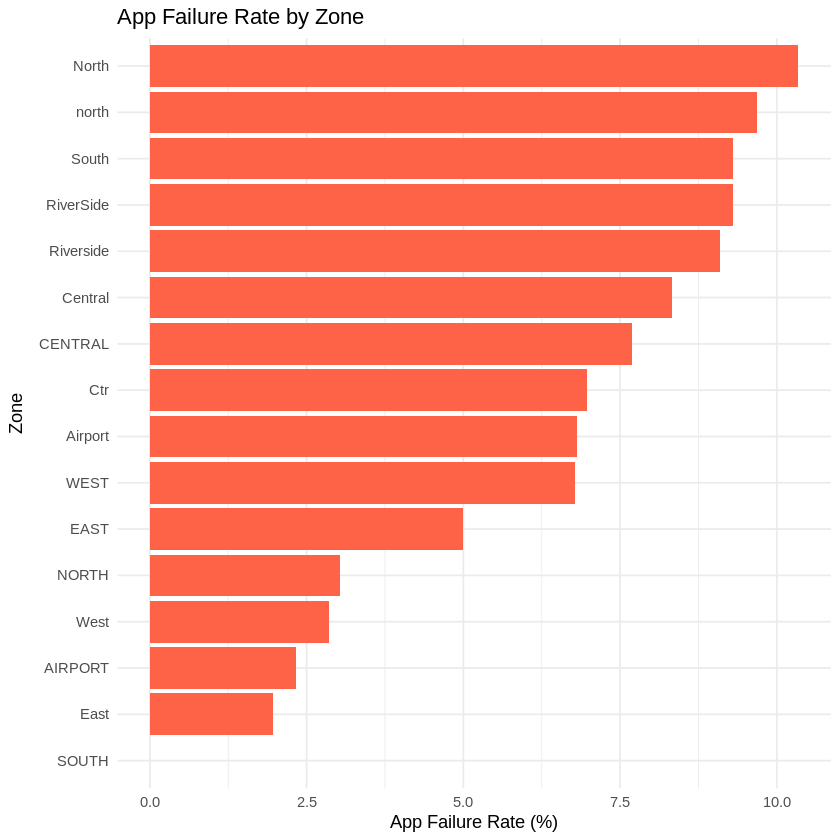

In [42]:
app_failure_plot <- app_events %>%
  group_by(zone_context) %>%
  summarise(
    total_events = n(),
    failed_events = sum(success_flag == 0, na.rm = TRUE),
    failure_rate_percent = failed_events * 100 / total_events,
    avg_latency = mean(api_latency_ms, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate_percent))

ggplot(app_failure_plot, aes(x = reorder(zone_context, failure_rate_percent), y = failure_rate_percent)) +
  geom_col(fill = "tomato") +
  coord_flip() +
  labs(
    title = "App Failure Rate by Zone",
    x = "Zone",
    y = "App Failure Rate (%)"
  ) +
  theme_minimal()